In [ ]:
#| default_exp hyper_account

In [ ]:
from token_data.hyperliquid import *
from hyperliquid.utils import constants

In [ ]:
address, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)

Running with account address: 0x143E18B563C4aD6913a9D89C774fE69A54F66cAa
Running with agent address: 0x0486f56Bf31b2E3B880248dAcd1BFf3C8bdC09e0


In [ ]:

# Get user state which contains balance information
user_state = info.user_state(address)

# Extract margin summary with account value
margin_summary = user_state["marginSummary"]
account_value = float(margin_summary["accountValue"])

print(f"Account Value: ${account_value:,.2f}")

# Get spot balances
spot_user_state = info.spot_user_state(address)
spot_balances = spot_user_state["balances"]

print("\nSpot Balances:")
for balance in spot_balances:
    coin = balance["coin"]
    total = float(balance["total"])
    hold = float(balance.get("hold", 0))
    available = total - hold
    print(f"  {coin}: {total:.6f} (Available: {available:.6f}, Hold: {hold:.6f})")

# Get perpetual positions
perp_positions = user_state.get("assetPositions", [])

if perp_positions:
    print("\nPerpetual Positions:")
    for position in perp_positions:
        if position["position"]["szi"] != "0":  # Only show non-zero positions
            coin = position["position"]["coin"]
            size = float(position["position"]["szi"])
            entry_px = float(position["position"]["entryPx"])
            unrealized_pnl = float(position["position"]["unrealizedPnl"])
            print(f"  {coin}: Size={size:.4f}, Entry=${entry_px:.2f}, PnL=${unrealized_pnl:.2f}")

Account Value: $27.71

Spot Balances:
  USDC: 11.285100 (Available: 11.285100, Hold: 0.000000)
  UETH: 0.005496 (Available: 0.005496, Hold: 0.000000)

Perpetual Positions:
  ETH: Size=-0.0053, Entry=$4293.89, PnL=$0.70


## Account trades

Function to list all trades and fills for a given account.

In [ ]:
#| export
def get_user_fills(address, info=None, aggregated=False, include_hash_oid=False):
    """
    Retrieves user fill history from Hyperliquid and returns as a DataFrame.
    
    Args:
        address (str): User's wallet address
        info (Info, optional): Hyperliquid Info client. If None, creates a new one.
        aggregated (bool, optional): If True, returns aggregated fills. Defaults to False.
    
    Returns:
        pandas.DataFrame: DataFrame containing fill data indexed by datetime with columns:
            - coin: Trading pair/coin
            - px: Fill price
            - sz: Fill size
            - side: Trade side (A for ask/sell, B for bid/buy)
            - time: Original timestamp in milliseconds
            - startPosition: Position size before fill
            - dir: Direction of trade
            - closedPnl: Realized PnL from closing position
            - hash: Transaction hash
            - oid: Order ID
            - crossed: Whether order crossed the spread
            - fee: Trading fee paid
            - tid: Trade ID
            - feeToken: Token used for fee payment
        Returns None if no fills found or error occurs.
    
    Examples:
        # Get all user fills
        fills_df = get_user_fills(address, info=info)
        
        # Get aggregated fills
        fills_df = get_user_fills(address, info=info, aggregated=True)
        
        # Filter for specific coin
        eth_fills = fills_df[fills_df['coin'] == 'ETH']
        
        # Calculate total fees paid
        total_fees = fills_df['fee'].sum()
    
    Notes:
        - DataFrame is indexed by datetime (converted from milliseconds)
        - All numeric columns are converted to float for calculations
        - Sorted by datetime in ascending order
    """
    # Initialize info client if not provided
    if info is None:
        from hyperliquid.info import Info
        from hyperliquid.utils import constants
        address_temp, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)
    
    try:
        # Get user fills
        if aggregated:
            user_fills = info.user_fills(address, aggregated=True)
        else:
            user_fills = info.user_fills(address)
        
        if not user_fills:
            print("No fills found for this address")
            return None
        
        # Convert to DataFrame
        fills_df = pd.DataFrame(user_fills)
        
        # Convert timestamp to datetime
        fills_df['datetime'] = pd.to_datetime(fills_df['time'], unit='ms')
        
        # Convert numeric columns to float
        numeric_cols = ['px', 'sz', 'startPosition', 'closedPnl', 'fee']
        for col in numeric_cols:
            if col in fills_df.columns:
                fills_df[col] = fills_df[col].astype(float)
        
        # Set datetime as index
        fills_df = fills_df.set_index('datetime')
        
        # Sort by datetime
        fills_df = fills_df.sort_index()
        
        # Add human-readable side column
        if 'side' in fills_df.columns:
            fills_df['side_readable'] = fills_df['side'].map({'A': 'Sell', 'B': 'Buy'})
        
        fills_df['fee_usdc'] = fills_df.apply(
            lambda row: row['fee'] * row['px'] if row['feeToken'] != 'USDC' else row['fee'],
            axis=1
        )
        # Calculate fee in basis points (bps)
        # Fee in bps = (fee / (price * size)) * 10000
        fills_df['fee_bps'] = (fills_df['fee_usdc'] / (fills_df['px'] * fills_df['sz'])) * 10000

        # Drop hash and oid columns if not requested
        if not include_hash_oid:
            cols_to_drop = [col for col in ['hash', 'oid','tid','time'] if col in fills_df.columns]
            if cols_to_drop:
                fills_df = fills_df.drop(columns=cols_to_drop)

        return fills_df
        
    except Exception as e:
        print(f"Error retrieving user fills: {e}")
        return None

Total Fills: 4

Fills Summary:
Date Range: 2025-09-13 13:41:44.333000 to 2025-10-21 00:52:28.595000

Fills by Coin:
coin
@151    2
ETH     2
dtype: int64

Total Fees Paid: $0.01
Total Closed PnL: $0.00

Recent Fills:
                         coin      px      sz side  startPosition         dir  closedPnl  crossed  \
datetime                                                                                            
2025-09-13 13:41:44.333  @151  4716.2  0.0025    B       0.000000         Buy        0.0     True   
2025-09-13 13:45:17.196   ETH  4713.5  0.0023    A       0.000000  Open Short        0.0    False   
2025-10-21 00:51:35.312  @151  3974.8  0.0030    B       0.002498         Buy        0.0     True   
2025-10-21 00:52:28.595   ETH  3972.2  0.0030    A      -0.002300  Open Short        0.0     True   

                              fee feeToken twapId side_readable  fee_usdc   fee_bps  
datetime                                                                             
2025

In [ ]:
#| eval:false

fills_df = get_user_fills(address, info=info)

if fills_df is not None:
    print(f"Total Fills: {len(fills_df)}")
    print(f"\nFills Summary:")
    print(f"Date Range: {fills_df.index.min()} to {fills_df.index.max()}")
    print(f"\nFills by Coin:")
    print(fills_df.groupby('coin').size().sort_values(ascending=False))
    print(f"\nTotal Fees Paid: ${fills_df['fee'].sum():.2f}")
    print(f"Total Closed PnL: ${fills_df['closedPnl'].sum():.2f}")

Total Fills: 4

Fills Summary:
Date Range: 2025-09-13 13:41:44.333000 to 2025-10-21 00:52:28.595000

Fills by Coin:
coin
@151    2
ETH     2
dtype: int64

Total Fees Paid: $0.01
Total Closed PnL: $0.00


In [ ]:
#| eval:false
print(fills_df)

                         coin      px      sz side  startPosition         dir  closedPnl  crossed  \
datetime                                                                                            
2025-09-13 13:41:44.333  @151  4716.2  0.0025    B       0.000000         Buy        0.0     True   
2025-09-13 13:45:17.196   ETH  4713.5  0.0023    A       0.000000  Open Short        0.0    False   
2025-10-21 00:51:35.312  @151  3974.8  0.0030    B       0.002498         Buy        0.0     True   
2025-10-21 00:52:28.595   ETH  3972.2  0.0030    A      -0.002300  Open Short        0.0     True   

                              fee feeToken twapId side_readable  fee_usdc   fee_bps  
datetime                                                                             
2025-09-13 13:41:44.333  0.000002     UETH   None           Buy  0.008253  7.000000  
2025-09-13 13:45:17.196  0.001626     USDC   None          Sell  0.001626  1.499855  
2025-10-21 00:51:35.312  0.000002     UETH   None

## Funding rate history for personal account

Function to retrieve funding rate history for a personal account. This is what your account is paying or receiving in USDC per hour.

In [ ]:

#| export
def get_user_funding_history(address, start_date=None, end_date=None, lookback=30, info=None,include_hash_time=False):
    """
    Retrieves user funding payment history from Hyperliquid and returns as a DataFrame.
    
    Args:
        address (str): User's wallet address
        start_date (str, optional): Start date as string. Can be:
            - ISO format: "2024-01-15T10:30:00Z" or "2024-01-15T10:30:00"
            - Date only: "2024-01-15"
            - If None, calculated from lookback. Defaults to None.
        end_date (str, optional): End date as string (same formats as start_date).
            - If None, uses current UTC time. Defaults to None.
        lookback (int, optional): Number of days to look back from end_date if start_date is None.
            Defaults to 30.
        info (Info, optional): Hyperliquid Info client. If None, creates a new one.
    
    Returns:
        pandas.DataFrame: DataFrame containing funding payment data indexed by datetime with columns:
            - coin: Trading pair/coin
            - usdc: Funding payment amount in USDC (positive = received, negative = paid)
            - time: Original timestamp in milliseconds
        Returns None if no funding payments found or error occurs.
    
    Examples:
        # Get last 30 days of funding payments
        funding_df = get_user_funding_history(address, info=info)
        
        # Get funding for specific date range
        funding_df = get_user_funding_history(address, 
                                             start_date="2024-01-01",
                                             end_date="2024-01-31",
                                             info=info)
        
        # Calculate total funding received/paid
        total_funding = funding_df['usdc'].sum()
        
        # Get funding by coin
        funding_by_coin = funding_df.groupby('coin')['usdc'].sum()
    
    Notes:
        - DataFrame is indexed by datetime (converted from milliseconds)
        - Positive usdc values indicate funding received
        - Negative usdc values indicate funding paid
        - All numeric columns are converted to float for calculations
        - Sorted by datetime in ascending order
    """
    # Initialize info client if not provided
    if info is None:
        from hyperliquid.info import Info
        from hyperliquid.utils import constants
        address_temp, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)
    
    # Handle end_date
    if end_date is None:
        end_dt = pd.Timestamp.now()
    else:
        try:
            end_dt = pd.to_datetime(end_date)
        except Exception as e:
            print(f"Error parsing end_date '{end_date}': {e}")
            return None

    # Handle start_date
    if start_date is None:
        start_dt = end_dt - pd.Timedelta(days=lookback)
    else:
        try:
            start_dt = pd.to_datetime(start_date)
        except Exception as e:
            print(f"Error parsing start_date '{start_date}': {e}")
            return None
    
    # Convert to Unix milliseconds timestamps
    start_time_ms = int(start_dt.timestamp() * 1000)
    end_time_ms = int(end_dt.timestamp() * 1000)
    
    try:
        # Get user funding history
        funding_history = info.user_funding_history(address, start_time_ms, end_time_ms)
        
        if not funding_history:
            print("No funding payments found for this address in the specified period")
            return None
        
        # Flatten the nested dictionary structure
        flattened_data = []
        for record in funding_history:
            flat_record = {
                'time': record['time'],
                'hash': record['hash'],
                'coin': record['delta']['coin'],
                'usdc': float(record['delta']['usdc']),
                'szi': float(record['delta']['szi']),
                'fundingRate': float(record['delta']['fundingRate'])
            }
            flattened_data.append(flat_record)
        
        # Convert to DataFrame
        funding_df = pd.DataFrame(flattened_data)
        
        # Convert timestamp to datetime
        funding_df['datetime'] = pd.to_datetime(funding_df['time'], unit='ms')
        
        # Convert numeric columns to float
        numeric_cols = ['usdc', 'delta']
        for col in numeric_cols:
            if col in funding_df.columns:
                funding_df[col] = funding_df[col].astype(float)
        
        # Set datetime as index
        funding_df = funding_df.set_index('datetime')
        
        # Sort by datetime
        funding_df = funding_df.sort_index()
        
        # Drop hash and time columns if not requested
        if not include_hash_time:
            cols_to_drop = [col for col in ['hash', 'time'] if col in funding_df.columns]
            if cols_to_drop:
                funding_df = funding_df.drop(columns=cols_to_drop)
        
        return funding_df
        
    except Exception as e:
        print(f"Error retrieving user funding history: {e}")
        return None

In [ ]:
#| eval:false
# Get last 30 days of funding payments
funding_df = get_user_funding_history(address, info=info)

if funding_df is not None:
    print(f"Total Funding Records: {len(funding_df)}")
    print(f"\nDate Range: {funding_df.index.min()} to {funding_df.index.max()}")
    
    print(f"\nFunding Summary by Coin:")
    summary = funding_df.groupby('coin')['usdc'].agg(['sum', 'count', 'mean'])
    summary.columns = ['Total USDC', 'Count', 'Avg Payment']
    print(summary)
    

Total Funding Records: 388

Date Range: 2025-09-29 00:00:00 to 2025-10-28 13:00:00.109000

Funding Summary by Coin:
      Total USDC  Count  Avg Payment
coin                                
ETH     0.077975    388     0.000201


In [ ]:
#|eval:false
print(f"\nTotal Funding Received/Paid: ${funding_df['usdc'].sum():.2f}")
print(f"\nRecent Funding Payments:")
print(funding_df)


Total Funding Received/Paid: $0.08

Recent Funding Payments:
                        coin      usdc     szi   fundingRate
datetime                                                    
2025-09-29 00:00:00.000  ETH  0.000184 -0.0023  7.674000e-07
2025-09-30 00:00:00.000  ETH  0.002378 -0.0023  1.039360e-05
2025-10-01 00:00:00.000  ETH  0.002902 -0.0023  1.242730e-05
2025-10-02 00:00:00.000  ETH  0.003031 -0.0023  1.250000e-05
2025-10-03 00:00:00.000  ETH  0.003088 -0.0023  1.250000e-05
...                      ...       ...     ...           ...
2025-10-28 09:00:00.046  ETH  0.000273 -0.0053  1.250000e-05
2025-10-28 10:00:00.036  ETH  0.000273 -0.0053  1.250000e-05
2025-10-28 11:00:00.005  ETH  0.000272 -0.0053  1.250000e-05
2025-10-28 12:00:00.001  ETH  0.000272 -0.0053  1.250000e-05
2025-10-28 13:00:00.109  ETH  0.000273 -0.0053  1.250000e-05

[388 rows x 4 columns]


<Axes: title={'center': 'ETH Funding Payments'}, xlabel='datetime'>

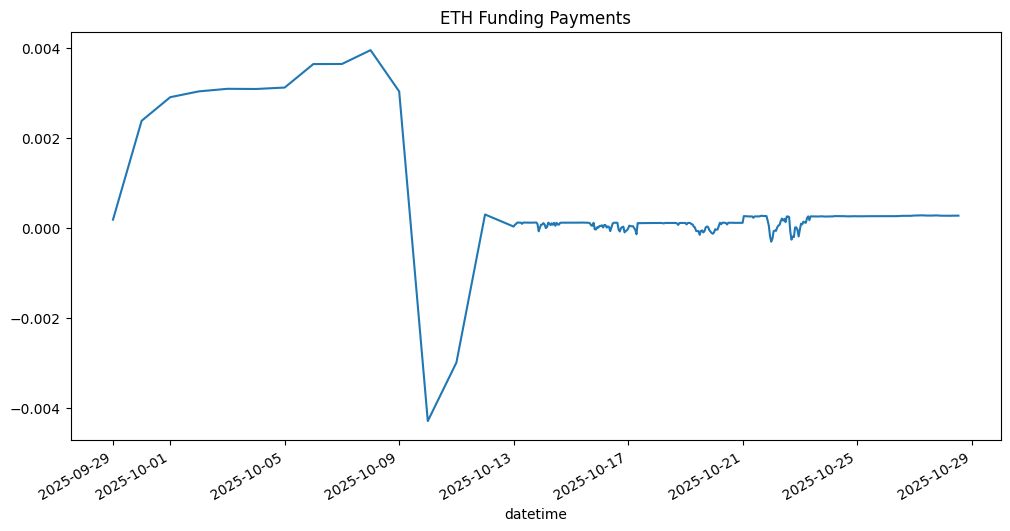

In [ ]:
#|eval:false
funding_df[funding_df['coin'] == 'ETH']['usdc'].plot(figsize=(12, 6), title="ETH Funding Payments")

<Axes: title={'center': 'ETH Funding Rate'}, xlabel='datetime'>

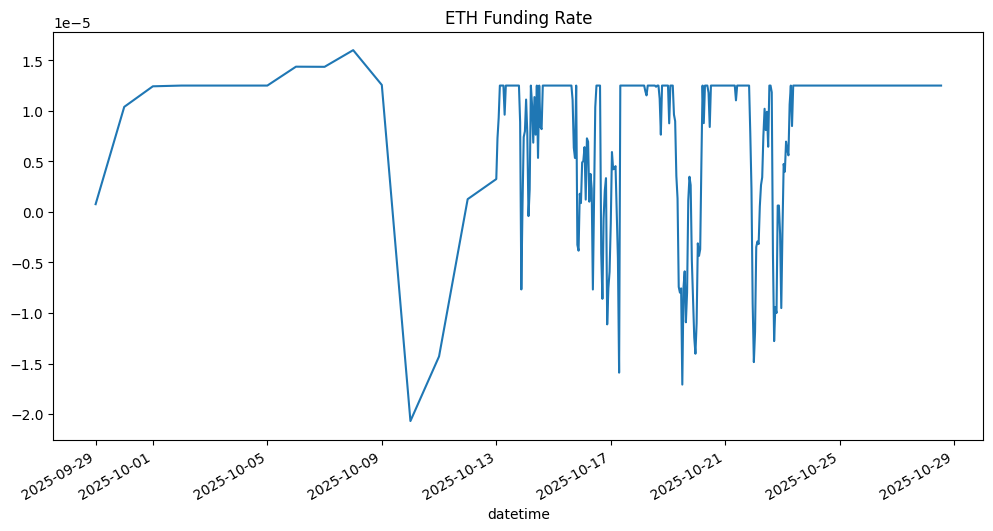

In [ ]:
#| eval:false
funding_df[funding_df['coin'] == 'ETH']['fundingRate'].plot(figsize=(12, 6), title="ETH Funding Rate")

<Axes: title={'center': 'Cumsum Funding Received/Paid'}, xlabel='datetime'>

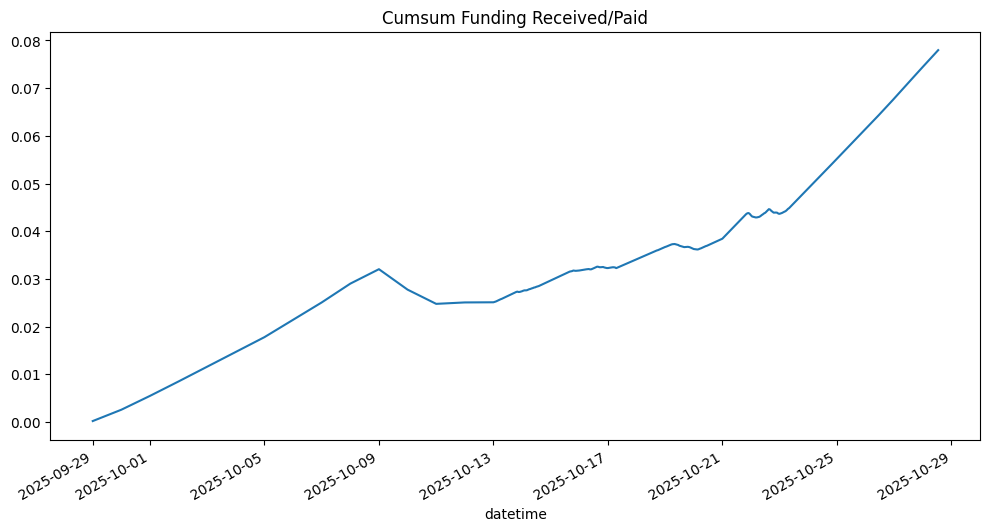

In [ ]:
#| eval:false
funding_df[funding_df['coin'] == 'ETH']['usdc'].cumsum().plot(figsize=(12, 6), title="Cumsum Funding Received/Paid")

## Account deposit and withdrawal events


In [ ]:
#|eval:false
print("Available Info methods related to funding:")
funding_methods = [method for method in dir(info) if 'fund' in method.lower()]
print(funding_methods)

Available Info methods related to funding:
['funding_history', 'user_funding_history', 'user_non_funding_ledger_updates']


In [ ]:

#| export
def get_user_ledger_updates(address, start_date=None, end_date=None, lookback=30, info=None, include_hash=False):
    """
    Retrieves user non-funding ledger updates from Hyperliquid and returns as a DataFrame.
    
    This function captures account events like deposits, withdrawals, transfers, and other
    non-funding related balance changes.
    
    Args:
        address (str): User's wallet address
        start_date (str, optional): Start date as string. Can be:
            - ISO format: "2024-01-15T10:30:00Z" or "2024-01-15T10:30:00"
            - Date only: "2024-01-15"
            - If None, calculated from lookback. Defaults to None.
        end_date (str, optional): End date as string (same formats as start_date).
            - If None, uses current UTC time. Defaults to None.
        lookback (int, optional): Number of days to look back from end_date if start_date is None.
            Defaults to 30.
        info (Info, optional): Hyperliquid Info client. If None, creates a new one.
        include_hash (bool, optional): If True, includes 'hash' column with transaction hashes.
            Defaults to False.
    
    Returns:
        pandas.DataFrame: DataFrame containing ledger update data indexed by datetime with columns:
            - type: Type of ledger update (e.g., 'deposit', 'withdraw', 'accountClassTransfer')
            - usdc: Amount in USDC
            - toPerp: For transfers, whether transfer was to perpetual account (True) or from (False)
            - hash: Transaction hash (only if include_hash=True)
        Returns None if no ledger updates found or error occurs.
    
    Examples:
        # Get last 30 days of ledger updates
        ledger_df = get_user_ledger_updates(address, info=info)
        
        # Get ledger updates for specific date range
        ledger_df = get_user_ledger_updates(address, 
                                           start_date="2024-01-01",
                                           end_date="2024-01-31",
                                           info=info)
        
        # Calculate total deposits
        deposits = ledger_df[ledger_df['type'] == 'deposit']['usdc'].sum()
        
        # Calculate total withdrawals
        withdrawals = ledger_df[ledger_df['type'] == 'withdraw']['usdc'].sum()
        
        # Get all transfers to perpetual account
        to_perp = ledger_df[(ledger_df['type'] == 'accountClassTransfer') & 
                           (ledger_df['toPerp'] == True)]
    
    Notes:
        - DataFrame is indexed by datetime (converted from milliseconds)
        - All numeric columns are converted to float for calculations
        - Sorted by datetime in ascending order
        - Does not include funding payments (use get_user_funding_history for that)
        - Common transaction types:
            * 'deposit': Deposits to account
            * 'withdraw': Withdrawals from account
            * 'accountClassTransfer': Transfers between spot and perpetual accounts
    """
    # Initialize info client if not provided
    if info is None:
        from hyperliquid.info import Info
        from hyperliquid.utils import constants
        address_temp, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)
    
    # Handle end_date
    if end_date is None:
        end_dt = pd.Timestamp.now()
    else:
        try:
            end_dt = pd.to_datetime(end_date)
        except Exception as e:
            print(f"Error parsing end_date '{end_date}': {e}")
            return None

    # Handle start_date
    if start_date is None:
        start_dt = end_dt - pd.Timedelta(days=lookback)
    else:
        try:
            start_dt = pd.to_datetime(start_date)
        except Exception as e:
            print(f"Error parsing start_date '{start_date}': {e}")
            return None
    
    # Convert to Unix milliseconds timestamps
    start_time_ms = int(start_dt.timestamp() * 1000)
    end_time_ms = int(end_dt.timestamp() * 1000)
    
    try:
        # Get user non-funding ledger updates
        ledger_updates = info.user_non_funding_ledger_updates(address, start_time_ms, end_time_ms)
        
        if not ledger_updates:
            print("No ledger updates found for this address in the specified period")
            return None
        
        # Flatten the nested dictionary structure
        flattened_data = []
        for record in ledger_updates:
            flat_record = {
                'time': record['time'],
                'hash': record['hash'],
                'type': record['delta']['type'],
                'usdc': float(record['delta']['usdc'])
            }
            
            # Add toPerp field if it exists (for accountClassTransfer)
            if 'toPerp' in record['delta']:
                flat_record['toPerp'] = record['delta']['toPerp']
            else:
                flat_record['toPerp'] = None
            
            flattened_data.append(flat_record)
        
        # Convert to DataFrame
        ledger_df = pd.DataFrame(flattened_data)
        
        # Convert timestamp to datetime
        ledger_df['datetime'] = pd.to_datetime(ledger_df['time'], unit='ms')
        
        # Set datetime as index
        ledger_df = ledger_df.set_index('datetime')
        
        # Sort by datetime
        ledger_df = ledger_df.sort_index()
        
        # Drop time column (we have datetime as index)
        ledger_df = ledger_df.drop(columns=['time'])
        
        # Drop hash column if not requested
        if not include_hash:
            ledger_df = ledger_df.drop(columns=['hash'])
        
        return ledger_df
        
    except Exception as e:
        print(f"Error retrieving user ledger updates: {e}")
        return None

In [ ]:

#| eval:false
# Test the function
ledger_df = get_user_ledger_updates(address, info=info, lookback=60)

if ledger_df is not None:
    print(f"Total Ledger Updates: {len(ledger_df)}")
    print(f"\nDate Range: {ledger_df.index.min()} to {ledger_df.index.max()}")
    
    print(f"\nLedger Updates by Type:")
    print(ledger_df.groupby('type').size().sort_values(ascending=False))
    
    print(f"\nSummary by Type:")
    summary = ledger_df.groupby('type')['usdc'].agg(['sum', 'count', 'mean'])
    summary.columns = ['Total USDC', 'Count', 'Avg Amount']
    print(summary)
    
    # Calculate net deposits/withdrawals
    deposits = ledger_df[ledger_df['type'] == 'deposit']['usdc'].sum()
    withdrawals = ledger_df[ledger_df['type'] == 'withdraw']['usdc'].sum()
    print(f"\nTotal Deposits: ${deposits:.2f}")
    print(f"Total Withdrawals: ${withdrawals:.2f}")
    print(f"Net Deposits: ${deposits - withdrawals:.2f}")
    
    # Show transfers between accounts
    transfers = ledger_df[ledger_df['type'] == 'accountClassTransfer']
    if len(transfers) > 0:
        to_perp = transfers[transfers['toPerp'] == True]['usdc'].sum()
        from_perp = transfers[transfers['toPerp'] == False]['usdc'].sum()
        print(f"\nTransfers to Perpetual: ${to_perp:.2f}")
        print(f"Transfers from Perpetual: ${from_perp:.2f}")
    
    print(f"\nLedger Updates:")
    print(ledger_df)

Total Ledger Updates: 4

Date Range: 2025-09-13 13:29:51.820000 to 2025-10-21 00:45:18.649000

Ledger Updates by Type:
type
accountClassTransfer    2
deposit                 2
dtype: int64

Summary by Type:
                      Total USDC  Count  Avg Amount
type                                               
accountClassTransfer        35.0      2       17.50
deposit                     61.9      2       30.95

Total Deposits: $61.90
Total Withdrawals: $0.00
Net Deposits: $61.90

Transfers to Perpetual: $0.00
Transfers from Perpetual: $35.00

Ledger Updates:
                                         type  usdc toPerp
datetime                                                  
2025-09-13 13:29:51.820               deposit  30.0   None
2025-09-13 13:31:44.867  accountClassTransfer  15.0  False
2025-10-21 00:41:50.464               deposit  31.9   None
2025-10-21 00:45:18.649  accountClassTransfer  20.0  False


In [ ]:

#| eval:false
# Check the help documentation for user_fees
#help(info.user_fees)
#help(info.user_state)

In [ ]:
info.user_state(address) # only perpetual account state

{'marginSummary': {'accountValue': '27.972596',
  'totalNtlPos': '21.79519',
  'totalRawUsd': '49.767786',
  'totalMarginUsed': '21.79519'},
 'crossMarginSummary': {'accountValue': '27.972596',
  'totalNtlPos': '21.79519',
  'totalRawUsd': '49.767786',
  'totalMarginUsed': '21.79519'},
 'crossMaintenanceMarginUsed': '0.435903',
 'withdrawable': '6.177406',
 'assetPositions': [{'type': 'oneWay',
   'position': {'coin': 'ETH',
    'szi': '-0.0053',
    'leverage': {'type': 'cross', 'value': 1},
    'entryPx': '4293.89',
    'positionValue': '21.79519',
    'unrealizedPnl': '0.96246',
    'returnOnEquity': '0.0422917129',
    'liquidationPx': '9206.0277469478',
    'marginUsed': '21.79519',
    'maxLeverage': 25,
    'cumFunding': {'allTime': '-0.117124',
     'sinceOpen': '-0.117124',
     'sinceChange': '-0.040911'}}}],
 'time': 1761677979886}

In [ ]:
info.spot_user_state(address) # only spot account state

{'balances': [{'coin': 'USDC',
   'token': 0,
   'total': '11.2851',
   'hold': '0.0',
   'entryNtl': '0.0'},
  {'coin': 'UETH',
   'token': 221,
   'total': '0.00549615',
   'hold': '0.0',
   'entryNtl': '23.7149'}]}

In [ ]:
#| hide
def spot_tickers_here(coin="UETH", base='USDC',info=None):
    """
    Retrieves current tickers for a given coin.

    Args:
        coin (str, optional): Coin symbol (e.g. "ETH"). Defaults to "ETH".
        base (str, optional): Coin symbol (e.g. "USDC"). Defaults to "USDC".
        info (Info, optional): Hyperliquid Info client. If None, creates a new one.

    Returns:
        spot ticker (non intuitive symbol)
        Returns None if the API request fails or returns no data.

    Notes:
        - Requires Hyperliquid Info client to be initialized
    """
    if info is None:
        address, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)
    maps =info.spot_meta_and_asset_ctxs()
    # Find the index of the coin and base in the universe of tokens
    # If not found, return None
    id_coin, id_base = None, None
    for token_ctx in maps[0]['tokens']:
        if token_ctx['name'] == coin:
            id_coin = token_ctx['index']
        elif token_ctx['name'] == base:
            id_base = token_ctx['index']
    if id_coin is None or id_base is None:
        return None
    for i in maps[0]['universe']:
        if i['tokens'] == [id_coin,id_base]:
            return i['name']
    id_coin, id_base = None, None
    for token_ctx in maps[0]['tokens']:
        if token_ctx['name'] == coin:
            id_coin = token_ctx['index']
        elif token_ctx['name'] == base:
            id_base = token_ctx['index']
    if id_coin is None or id_base is None:
        return None
    for i in maps['universe']:
        if i['tokens'] == [id_coin,id_base]:
            return i['name']
    return None                

In [ ]:
#| export
def get_account_summary(address, info=None, lookback_days=3650):
    """
    Retrieves a comprehensive account summary including deposits, withdrawals, and current value.
    
    Args:
        address (str): User's wallet address
        info (Info, optional): Hyperliquid Info client. If None, creates a new one.
        lookback_days (int, optional): Number of days to look back for ledger history. 
            Defaults to 3650 (~10 years).
    
    Returns:
        dict: Dictionary containing:
            - total_deposits (float): Total amount deposited in USDC
            - total_withdrawals (float): Total amount withdrawn in USDC
            - net_deposits (float): Net deposits (deposits - withdrawals) in USDC
            - current_value (float): Current total account value in USDC
            - spot_value (float): Value in spot account in USDC
            - perp_margin (float): Margin in perpetual account in USDC
            - perp_position_value (float): Current notional value of perpetual positions in USDC
            - total_pnl (float): Total profit/loss (current_value - net_deposits)
            - pnl_percentage (float): P&L as percentage of net deposits
            - unrealized_pnl (float): Unrealized P&L from open perpetual positions
        Returns None if error occurs.
    
    Examples:
        # Get account summary
        summary = get_account_summary(address, info=info)
        
        if summary:
            print(f"Net Deposits: ${summary['net_deposits']:,.2f}")
            print(f"Current Value: ${summary['current_value']:,.2f}")
            print(f"Total P&L: ${summary['total_pnl']:,.2f} ({summary['pnl_percentage']:.2f}%)")
    
    Notes:
        - All values are in USDC
        - P&L includes both realized and unrealized gains/losses
        - Current value = spot balance + perp margin + current position values
        - Uses current market prices from info.all_mids() to value positions
        - Requires access to user_state, spot_user_state, and ledger updates
    """
    # Initialize info client if not provided
    if info is None:
        from hyperliquid.info import Info
        from hyperliquid.utils import constants
        address_temp, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)
    
    try:
        # Get ledger updates for deposits/withdrawals
        ledger_df = get_user_ledger_updates(address, info=info, lookback=lookback_days)
        
        if ledger_df is not None:
            deposits = ledger_df[ledger_df['type'] == 'deposit']['usdc'].sum()
            withdrawals = ledger_df[ledger_df['type'] == 'withdraw']['usdc'].sum()
            net_deposits = deposits - withdrawals
        else:
            deposits = 0
            withdrawals = 0
            net_deposits = 0
        
        # Get current market prices
        all_mids = info.all_mids()
        
        # Get user state for perpetual account
        user_state = info.user_state(address)
        margin_summary = user_state["marginSummary"]
        
        # Get margin value (this is the collateral in perp account)
        perp_margin = float(margin_summary["accountValue"])
        
        # Get spot balances
        spot_user_state = info.spot_user_state(address)
        spot_balances = spot_user_state["balances"]

        # Calculate spot value using current prices
        spot_value = 0
        positions = []
        for balance in spot_balances:
            coin = balance["coin"]
            if coin != "USDC":
                coin = spot_tickers_here(coin=coin, base='USDC',info=info)
            total = float(balance["total"])
            
            if coin == "USDC":
                spot_value += total
                current_price = 1.0
                usdc_value = total
            else:
                # Get current price for this coin
                current_price = float(all_mids.get(coin, 0))
                usdc_value = total * current_price
                spot_value += usdc_value

            positions.append({
                    'coin': coin,
                    'signed_position': total,
                    'price': current_price,
                    'current_usdc_value': usdc_value,
                    'unrealized_pnl': 0.0,  # Spot positions don't have unrealized PnL tracked
                    'asset_type': 'spot'
                })
        
        # Get perpetual positions and calculate their current value
        perp_positions = user_state.get("assetPositions", [])
        unrealized_pnl = 0
        position_notional = 0
        
        for position in perp_positions:
            if position["position"]["szi"] != "0":  # Only non-zero positions
                coin = position["position"]["coin"]
                size = float(position["position"]["szi"])
                unrealized = float(position["position"]["unrealizedPnl"])
                
                # Get current market price
                current_price = float(all_mids.get(coin, 0))
                
                unrealized_pnl += unrealized
                # Current notional value = abs(size) * current_price
                usdc_value = abs(size) * current_price
                position_notional += usdc_value
                positions.append({
                    'coin': coin,
                    'signed_position': size,
                    'price': current_price,
                    'current_usdc_value': usdc_value,
                    'unrealized_pnl': unrealized,
                    'asset_type': 'perp'
                })

        positions_df = pd.DataFrame(positions)
        # Total current value = spot value + perp margin + current position values
        current_value = spot_value + perp_margin #+ position_notional
        
        # Calculate P&L
        total_pnl = current_value - net_deposits
        pnl_percentage = (total_pnl / net_deposits * 100) if net_deposits > 0 else 0
        
        summary = {
            'total_deposits': deposits,
            'total_withdrawals': withdrawals,
            'net_deposits': net_deposits,
            'current_value': current_value,
            'spot_value': spot_value,
            'perp_margin': perp_margin,
            'perp_position_value': position_notional,
            'total_pnl': total_pnl,
            'pnl_percentage': pnl_percentage,
            'unrealized_pnl': unrealized_pnl
        }
        return summary, positions_df
        
    except Exception as e:
        print(f"Error retrieving account summary: {e}")
        return None

In [ ]:

#| eval:false
# Test the corrected account summary function
summary,df = get_account_summary(address, info=info)

if summary:
    print("=" * 60)
    print("ACCOUNT SUMMARY")
    print("=" * 60)
    print(f"\nDeposit/Withdrawal History:")
    print(f"  Total Deposits:    ${summary['total_deposits']:,.2f}")
    print(f"  Total Withdrawals: ${summary['total_withdrawals']:,.2f}")
    print(f"  Net Deposits:      ${summary['net_deposits']:,.2f}")
    
    print(f"\nCurrent Account Value:")
    print(f"  Total Value:       ${summary['current_value']:,.2f}")
    print(f"    Spot Balance:    ${summary['spot_value']:,.2f}")
    print(f"    Perp Margin:     ${summary['perp_margin']:,.2f}")
    
    print(f"\nPerpetual Positions:")
    print(f"  Position Notional: ${summary['perp_position_value']:,.2f}")
    print(f"  Unrealized PnL:    ${summary['unrealized_pnl']:,.2f}")
    
    print(f"\nProfit/Loss:")
    print(f"  Total P&L:         ${summary['total_pnl']:,.2f}")
    print(f"  P&L Percentage:    {summary['pnl_percentage']:.2f}%")
    print("=" * 60)

ACCOUNT SUMMARY

Deposit/Withdrawal History:
  Total Deposits:    $61.90
  Total Withdrawals: $0.00
  Net Deposits:      $61.90

Current Account Value:
  Total Value:       $61.87
    Spot Balance:    $33.62
    Perp Margin:     $28.26

Perpetual Positions:
  Position Notional: $21.53
  Unrealized PnL:    $1.25

Profit/Loss:
  Total P&L:         $-0.03
  P&L Percentage:    -0.04%


In [ ]:
#info.user_state(address) #'accountValue': '28.260658' is the account balance for the perps
# that includes the position and the margin ....
#'positionValue': '21.5074', is the size*price 

{'marginSummary': {'accountValue': '28.260658',
  'totalNtlPos': '21.5074',
  'totalRawUsd': '49.768058',
  'totalMarginUsed': '21.5074'},
 'crossMarginSummary': {'accountValue': '28.260658',
  'totalNtlPos': '21.5074',
  'totalRawUsd': '49.768058',
  'totalMarginUsed': '21.5074'},
 'crossMaintenanceMarginUsed': '0.430148',
 'withdrawable': '6.753258',
 'assetPositions': [{'type': 'oneWay',
   'position': {'coin': 'ETH',
    'szi': '-0.0053',
    'leverage': {'type': 'cross', 'value': 1},
    'entryPx': '4293.89',
    'positionValue': '21.5074',
    'unrealizedPnl': '1.25025',
    'returnOnEquity': '0.0549375704',
    'liquidationPx': '9206.0780614132',
    'marginUsed': '21.5074',
    'maxLeverage': 25,
    'cumFunding': {'allTime': '-0.117396',
     'sinceOpen': '-0.117396',
     'sinceChange': '-0.041183'}}}],
 'time': 1761679246607}

In [ ]:
#maps =info.spot_meta_and_asset_ctxs()
#maps

[{'universe': [{'tokens': [1, 0],
    'name': 'PURR/USDC',
    'index': 0,
    'isCanonical': True},
   {'tokens': [2, 0], 'name': '@1', 'index': 1, 'isCanonical': False},
   {'tokens': [3, 0], 'name': '@2', 'index': 2, 'isCanonical': False},
   {'tokens': [4, 0], 'name': '@3', 'index': 3, 'isCanonical': False},
   {'tokens': [5, 0], 'name': '@4', 'index': 4, 'isCanonical': False},
   {'tokens': [6, 0], 'name': '@5', 'index': 5, 'isCanonical': False},
   {'tokens': [7, 0], 'name': '@6', 'index': 6, 'isCanonical': False},
   {'tokens': [8, 0], 'name': '@7', 'index': 7, 'isCanonical': False},
   {'tokens': [9, 0], 'name': '@8', 'index': 8, 'isCanonical': False},
   {'tokens': [10, 0], 'name': '@9', 'index': 9, 'isCanonical': False},
   {'tokens': [11, 0], 'name': '@10', 'index': 10, 'isCanonical': False},
   {'tokens': [12, 0], 'name': '@11', 'index': 11, 'isCanonical': False},
   {'tokens': [13, 0], 'name': '@12', 'index': 12, 'isCanonical': False},
   {'tokens': [14, 0], 'name': '@13',